In [6]:
%load_ext autoreload
%autoreload 2

from datetime import date, datetime, timedelta
from functools import partial
from typing import Dict, Optional

import numpy as np
import polars as pl
from tqdm import tqdm
import matplotlib.pyplot as plt

from okx.store import OrderbookStore
from okx.recipes.forwards import build_forwards_pchip, build_forwards_kalman, assign_forwards
from okx.recipes.options import prepare_options
from okx.recipes.parity import prepare_market_snapshots, calculate_parity_arbitrage, summarize_parity_arbitrage, aggregate_best_synthetics

from evaluation.forwards_eval import evaluate_parity, summarize_parity, evaluate_pillar_fit, evaluate_loeo, summarize_pillar_fit, run_full_evaluation
from evaluation.plotting import plot_error_histogram, plot_error_over_time, plot_error_by_group

store = OrderbookStore(
    data_root="data/okx",
    manifest_path="data/okx/manifest.sqlite"
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
def make_dates(start_date, n):
    return [start_date + timedelta(days=i) for i in range(n)]

binning = '30s'
dates = make_dates(date(2025, 8, 1), 31)
print(f"Dates selected from {dates[0]} to {dates[-1]}")

Dates selected from 2025-08-01 to 2025-08-31


In [23]:
parity = calculate_parity_arbitrage(
    store,
    inst_family = 'BTC-USD',
    dates = dates,
    binning = binning,
    assets = 6_000_000,
    volume = 60_000_000,
    max_return = 10.0,
    verbose = True,
    batch_days = 5,
)

Calculating parity arbitrage opportunities...
Constructing market snapshots for BTC-USD with 30s binning
[store] Getting BTC-USD/FUTURES for 31 dates (depth=1, 30s binning, 6 features)


Processing batches:   0%|          | 0/7 [00:00<?, ?it/s]

[store] Getting BTC-USD/OPTION for 31 dates (depth=1, 30s binning, 7 features)


Processing batches:   0%|          | 0/7 [00:00<?, ?it/s]

[store] Getting BTC-USD/SPOT for 31 dates (depth=0, 30s binning, 4 features)


Processing batches:   0%|          | 0/7 [00:00<?, ?it/s]

 - Time taken to construct market snapshots: 0:01:59.990858
     VIP 4 options fees: maker=0.0150%, taker=0.0200%
     VIP 8 futures fees: maker=-0.0500%, taker=0.0800%
  Time taken: 0:01:59.992141


In [24]:
_ = summarize_parity_arbitrage(
    parity,
    order_types = None,
    verbose = True,
)


=== PARITY ARBITRAGE SUMMARY ===

LONG_LMT_Cb_Pa (LONG LMT):
  Count: 8,389,899 | Frequency: 61.16%
  Avg Profit: $1906.18 | Max: $154269.07
  Avg Capital: $21108.99
  Avg Return: 50.32% | Annual: inf%

LONG_SYM_Cb_Pb (LONG SYM):
  Count: 6,021,911 | Frequency: 43.90%
  Avg Profit: $2135.68 | Max: $97458.75
  Avg Capital: $28659.60
  Avg Return: 50.95% | Annual: inf%

LONG_SYM_Ca_Pa (LONG SYM):
  Count: 5,292,021 | Frequency: 38.58%
  Avg Profit: $1129.10 | Max: $148314.44
  Avg Capital: $27416.99
  Avg Return: 2.77% | Annual: 99.59%

LONG_MKT_Ca_Pb (LONG MKT):
  Count: 3,643,419 | Frequency: 26.56%
  Avg Profit: $5559.74 | Max: $77050.71
  Avg Capital: $174845.71
  Avg Return: 2.53% | Annual: 42.05%

SHORT_LMT_Ca_Pb (SHORT LMT):
  Count: 5,767,573 | Frequency: 42.05%
  Avg Profit: $2051.82 | Max: $148426.21
  Avg Capital: $12182.80
  Avg Return: 76.72% | Annual: inf%

SHORT_SYM_Ca_Pa (SHORT SYM):
  Count: 2,598,570 | Frequency: 18.94%
  Avg Profit: $1236.00 | Max: $120067.23
  Avg Ca

In [25]:
parity_df = parity.collect()

In [35]:
name = 'LONG_MKT_Ca_Pb'
(
    parity_df.filter(pl.col(f'{name}_profitable') & (pl.col(f'{name}_annual_return').is_not_nan()))
    .sort(f'{name}_annual_return', descending=True)
    .select('timeMs', 'BTC-USD', 'F_mid', 'T', 'strike', 'call_ask_qty', 'call_ask', 'put_bid_qty', 'put_bid', f'{name}_fwd', f'{name}_annual_return', f'{name}_capital', f'{name}_profit', f'{name}_size')
).head()

timeMs,BTC-USD,F_mid,T,strike,call_ask_qty,call_ask,put_bid_qty,put_bid,LONG_MKT_Ca_Pb_fwd,LONG_MKT_Ca_Pb_annual_return,LONG_MKT_Ca_Pb_capital,LONG_MKT_Ca_Pb_profit,LONG_MKT_Ca_Pb_size
i64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1755886470000,117417.95,117543.95,0.018009,90000,10.0,0.2045,776.0,0.0001,114099.068843,1666.323745,2409.906884,344.483116,10.0
1755886440000,117399.95,117525.05,0.01801,90000,10.0,0.2045,776.0,0.0001,114095.373786,1617.061781,2409.537379,342.962621,10.0
1755886500000,117400.05,117516.55,0.018008,90000,10.0,0.2045,776.0,0.0001,114095.38743,1590.738897,2409.538743,342.111257,10.0
1755886560000,117383.95,117500.1,0.018006,90000,10.0,0.2045,756.0,0.0001,114092.080891,1544.381167,2409.208089,340.561911,10.0
1755886380000,117354.05,117481.95,0.018012,90000,10.0,0.2045,746.0,0.0001,114085.955068,1512.071835,2408.595507,339.544493,10.0


In [40]:
metrics_lf = aggregate_best_synthetics(
    parity,
    verbose = True,
)

from okx.features import times_to_dt

metrics_lf = times_to_dt(metrics_lf)

print(metrics_lf.explain(optimized=False))

Aggregating best synthetic prices across strikes...
  Aggregated best prices per timestamp (including F_mid)
 WITH_COLUMNS:
 [col("timeMs").strict_cast(Datetime('ms'))] 
  SORT BY [col("timeMs")]
    AGGREGATE[maintain_order: false]
      [col("F_mid").first(), col("LONG_MKT_Ca_Pb_fwd").min().alias("best_market_long"), col("SHORT_MKT_Cb_Pa_fwd").max().alias("best_market_short"), col("LONG_SYM_Cb_Pb_fwd").min().min_horizontal([col("LONG_SYM_Ca_Pa_fwd").min()]).alias("best_sym_long"), col("SHORT_SYM_Ca_Pa_fwd").max().max_horizontal([col("SHORT_SYM_Cb_Pb_fwd").max()]).alias("best_sym_short")] BY [col("timeMs")]
      FROM
       WITH_COLUMNS:
       [[(col("strike").cast(Float64)) + ([([([([([(col("call_bid")) + (0.0001)]) * (col("BTC-USD"))]) - ([([(col("put_ask")) - (0.0001)]) * (col("BTC-USD"))])]) + ([([([([(col("call_bid")) + (0.0001)]) * (col("BTC-USD"))]) * (0.00015)]) + ([([([(col("put_ask")) - (0.0001)]) * (col("BTC-USD"))]) * (0.00015)])])]) + ([(col("F_bid")) * (0.0008)])])].al

In [41]:
metrics = metrics_lf.collect()

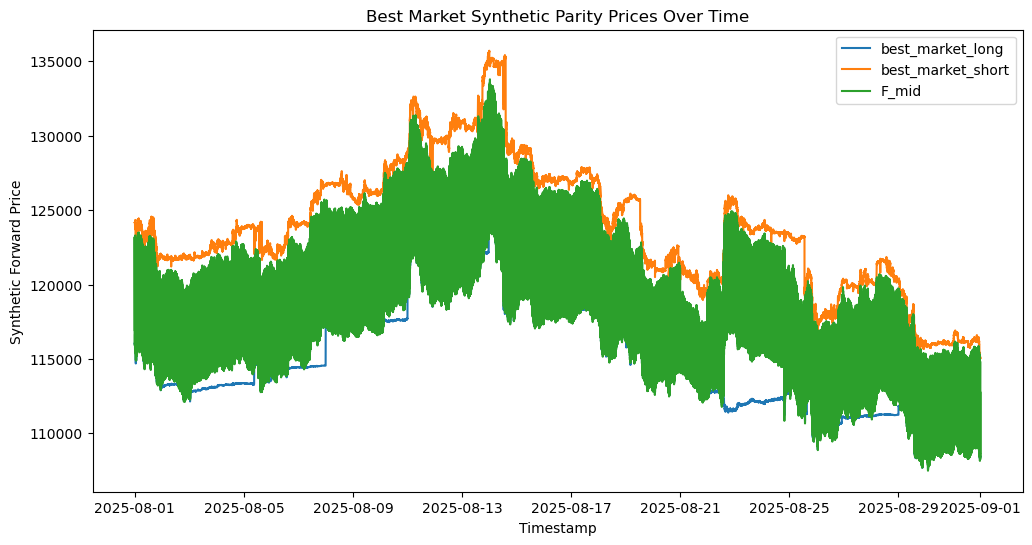

In [43]:
cols = ['best_market_long', 'best_market_short', 'F_mid']
plt.figure(figsize=(12, 6))
for col in cols:
    plt.plot(metrics['timeMs'], metrics[col], label=col)
plt.xlabel('Timestamp')
plt.ylabel('Synthetic Forward Price')
plt.title('Best Market Synthetic Parity Prices Over Time')
plt.legend()
plt.show()

In [ ]:
# Show top profitable opportunities for market orders (most conservative)
import polars as pl

# Set Polars to not abbreviate or truncate column output in print statements
pl.Config.set_tbl_cols(-1)  # Show all columns, no abbreviation

print("=== TOP LONG SYNTHETIC (Market Order) ARBITRAGE OPPORTUNITIES ===\n")
long_arbs = (
    merged
    .filter(pl.col('LONG_MKT_Ca_Pb_profitable'))
    .select([
        'timeMs', 'expiry', 'T', 'strike', 'moneyness',
        'F_bid', 'LONG_MKT_Ca_Pb_fwd', 'LONG_MKT_Ca_Pb_cost',
        'LONG_MKT_Ca_Pb_profit', 'LONG_MKT_Ca_Pb_return', 'LONG_MKT_Ca_Pb_capital', 'LONG_MKT_Ca_Pb_annual_return'
    ])
    .sort('LONG_MKT_Ca_Pb_profit', descending=True)
    .head(10)
    .collect()
)
print(long_arbs)

print("\n=== TOP SHORT SYNTHETIC (Market Order) ARBITRAGE OPPORTUNITIES ===\n")
short_arbs = (
    merged
    .filter(pl.col('SHORT_MKT_Cb_Pa_profitable'))
    .select([
        'timeMs', 'expiry', 'T', 'strike', 'moneyness',
        'F_ask', 'SHORT_MKT_Cb_Pa_fwd', 'SHORT_MKT_Cb_Pa_cost',
        'SHORT_MKT_Cb_Pa_profit', 'SHORT_MKT_Cb_Pa_return', 'SHORT_MKT_Cb_Pa_capital', 'SHORT_MKT_Cb_Pa_annual_return'
    ])
    .sort('SHORT_MKT_Cb_Pa_profit', descending=True)
    .head(10)
    .collect()
)
print(short_arbs)


=== TOP LONG SYNTHETIC (Market Order) ARBITRAGE OPPORTUNITIES ===

shape: (10, 12)
┌────────┬────────┬────────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┐
│ timeMs ┆ expiry ┆ T      ┆ strik ┆ money ┆ F_bid ┆ LONG_ ┆ LONG_ ┆ LONG_ ┆ LONG_ ┆ LONG_ ┆ LONG_ │
│ ---    ┆ ---    ┆ ---    ┆ e     ┆ ness  ┆ ---   ┆ MKT_C ┆ MKT_C ┆ MKT_C ┆ MKT_C ┆ MKT_C ┆ MKT_C │
│ i64    ┆ i64    ┆ f64    ┆ ---   ┆ ---   ┆ f64   ┆ a_Pb_ ┆ a_Pb_ ┆ a_Pb_ ┆ a_Pb_ ┆ a_Pb_ ┆ a_Pb_ │
│        ┆        ┆        ┆ i64   ┆ f64   ┆       ┆ fwd   ┆ cost  ┆ profi ┆ retur ┆ capit ┆ annua │
│        ┆        ┆        ┆       ┆       ┆       ┆ ---   ┆ ---   ┆ t     ┆ n     ┆ al    ┆ l_ret │
│        ┆        ┆        ┆       ┆       ┆       ┆ f64   ┆ f64   ┆ ---   ┆ ---   ┆ ---   ┆ urn   │
│        ┆        ┆        ┆       ┆       ┆       ┆       ┆       ┆ f64   ┆ f64   ┆ f64   ┆ ---   │
│        ┆        ┆        ┆       ┆       ┆       ┆       ┆       ┆       ┆       ┆       ┆ f64   │
╞═══════

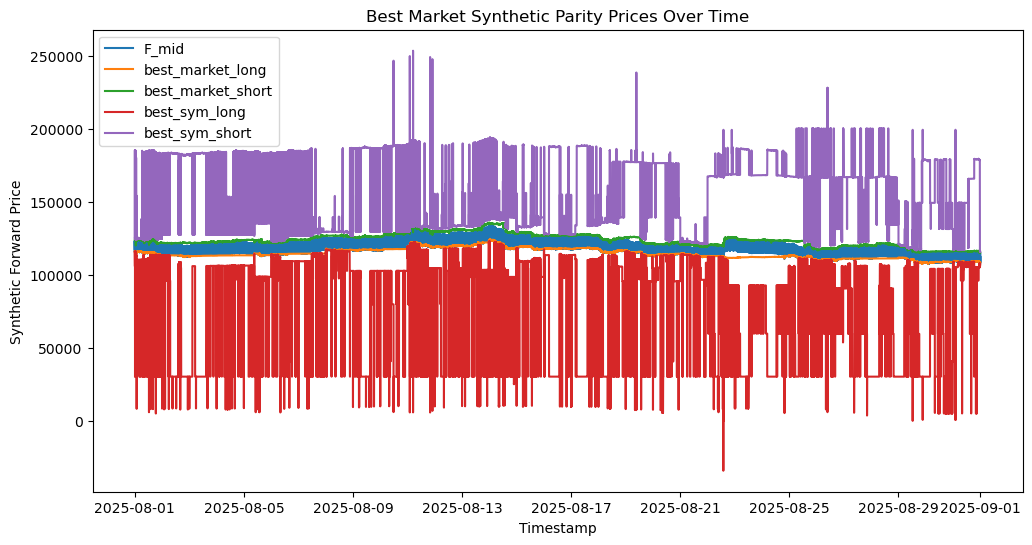

In [42]:
cols = [col for col in metrics.collect_schema().names() if col != 'timeMs']

plt.figure(figsize=(12, 6))
for col in cols:
    plt.plot(metrics['timeMs'], metrics[col], label=col)
plt.xlabel('Timestamp')
plt.ylabel('Synthetic Forward Price')
plt.title('Best Market Synthetic Parity Prices Over Time')
plt.legend()
plt.show()